<a href="https://colab.research.google.com/github/ksaad20/Digital-Signal-Processing-Mathematics-to-Code-/blob/main/Chapter_12_Fixed_Point_DSP_%26_Hardware_Consideration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

The Math: Fixed-point arithmetic vs. floating-point, word-length optimization, and finite word-length effects (limit cycles).

The Project: Design a bit-true Python simulation of an FIR filter optimized to run on an 8-bit microcontroller or an FPGA.

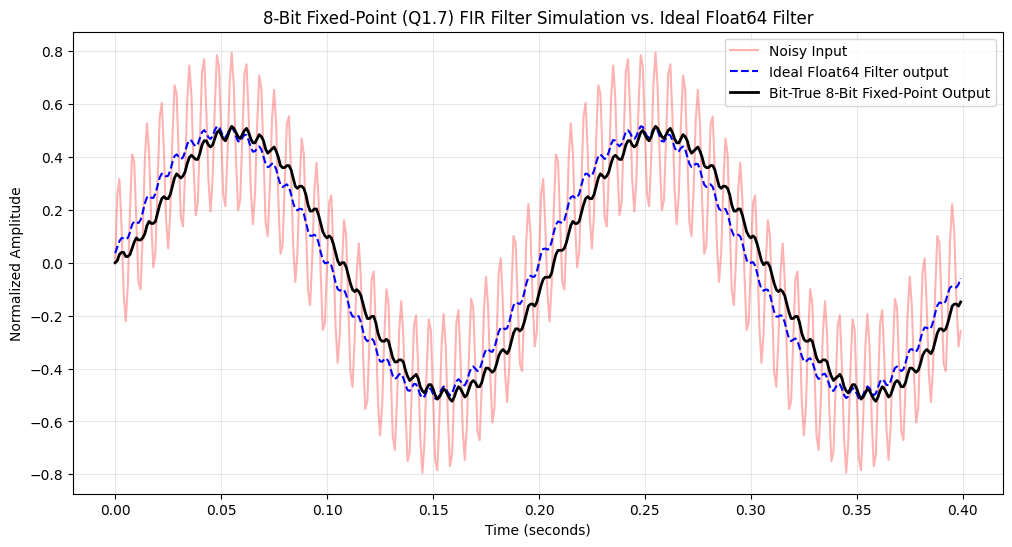

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def float_to_q17(val):
    """Converts a float into a signed 8-bit Q1.7 integer (-128 to 127)."""
    q_val = np.round(val * 128.0).astype(np.int16)
    return np.clip(q_val, -128, 127).astype(np.int8)

def q17_to_float(q_val):
    """Converts a signed 8-bit Q1.7 integer back to a float."""
    return q_val / 128.0

def hardware_fir_8bit(x_float, b_float):
    """
    Simulates an 8-bit hardware FIR filter executing on an explicit
    integer-only Multiplier-Accumulator (MAC) architecture.
    """
    # Quantize coefficients and inputs to 8-bit integers (Q1.7)
    b_q = float_to_q17(b_float)
    x_q = float_to_q17(x_float)

    N = len(x_q)
    M = len(b_q)
    y_q = np.zeros(N, dtype=np.int8)

    # Simulating the hardware Delay Line (Shift Register)
    delay_line = np.zeros(M, dtype=np.int8)

    for n in range(N):
        # Shift new sample into hardware register delay line
        for i in range(M - 1, 0, -1):
            delay_line[i] = delay_line[i - 1]
        delay_line[0] = x_q[n]

        # 16-bit wide hardware Accumulator register (int16)
        accumulator = 0

        # Hardware Multiply-Accumulate (MAC) Loop
        for i in range(M):
            # 8-bit x 8-bit multiplication yields a 16-bit result (Q2.14)
            product = int(delay_line[i]) * int(b_q[i])
            accumulator += product

        # Scale back from intermediate Q2.14 to system bus Q1.7 format
        # Bit-shift right by 7 is mathematically equivalent to dividing by 128
        output_sample = accumulator >> 7

        # Hardware Saturation Logic (Prevents two's complement roll-over wrapping)
        if output_sample > 127:
            output_sample = 127
        elif output_sample < -128:
            output_sample = -128

        y_q[n] = output_sample

    return q17_to_float(y_q)

# --- CONFIGURATION & TESTING PIPELINE ---
fs = 1000
t = np.arange(0, 0.4, 1/fs)

# Target signal (5 Hz) corrupted by high-frequency interference (150 Hz)
clean_signal = 0.5 * np.sin(2 * np.pi * 5 * t)
noise = 0.3 * np.sin(2 * np.pi * 150 * t)
corrupted_signal = clean_signal + noise

# Design a standard 15-tap floating-point lowpass FIR filter (Cutoff 30 Hz)
num_taps = 15
b_floating = np.sinc(2 * 30 / fs * (np.arange(num_taps) - (num_taps - 1) / 2))
b_floating /= np.sum(b_floating) # Normalize gain

# Run standard high-precision float64 filter
y_float64 = np.convolve(corrupted_signal, b_floating, mode='same')

# Run the bit-true hardware-accurate 8-bit fixed-point simulation
y_hardware_8bit = hardware_fir_8bit(corrupted_signal, b_floating)

# --- VISUALIZATION ---
plt.figure(figsize=(12, 6))
plt.plot(t, corrupted_signal, color='red', alpha=0.3, label='Noisy Input')
plt.plot(t, y_float64, color='blue', linestyle='--', label='Ideal Float64 Filter output')
plt.plot(t, y_hardware_8bit, color='black', linewidth=2, label='Bit-True 8-Bit Fixed-Point Output')
plt.title("8-Bit Fixed-Point (Q1.7) FIR Filter Simulation vs. Ideal Float64 Filter")
plt.xlabel("Time (seconds)")
plt.ylabel("Normalized Amplitude")
plt.grid(True, alpha=0.3)
plt.legend(loc="upper right")
plt.show()